In this notebook we will import a model trained on the OpenDPD dataset and perform neural network pruning using a range of inverse models.

In [ ]:
from sparseDPD import PGJANET_NeuralNetwork, PNTDNN_NeuralNetwork, ARVTDNN_NeuralNetwork
from sparseDPD import DataManager, Datapath, DatapathPruningExperiment, AdaptiveDatapathPruningExperiment

# load the OpenDPD dataset
# Same dataset/training style as refactored_notebook.ipynb
openDPD_folder = '../OpenDPD_datasets/DPA_160MHz'

#40,000 points
openDPD_dataManager = DataManager(
    num_test_points=98304,
    num_training_points=294912,
    num_validaiton_points=98304,
    openDPD_test_input_file=f'{openDPD_folder}/test_input.csv',
    openDPD_test_output_file=f'{openDPD_folder}/test_output.csv',
    openDPD_training_input_file=f'{openDPD_folder}/train_input.csv',
    openDPD_training_output_file=f'{openDPD_folder}/train_output.csv',
    openDPD_validation_input_file=f'{openDPD_folder}/val_input.csv',
    openDPD_validation_output_file=f'{openDPD_folder}/val_output.csv'
)

# Load forward model
PNTDNN_three_layer_forward_nn = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type='ThreeLayerNetwork', nn_file_path='../open_dpd_DPA_160MHz_forward_models/pntdnn_three_layer_open.pt')

Using cuda device


# PNTDNN one layer

Using cuda device
Epoch  10/50  Loss=8.1499e+00  Valid Loss=1.1127e+02  LR=1.00e-03
Epoch  20/50  Loss=7.6894e+00  Valid Loss=1.4146e+02  LR=1.00e-03
Epoch  30/50  Loss=7.4514e+00  Valid Loss=1.3111e+02  LR=5.00e-04
Epoch  40/50  Loss=7.3242e+00  Valid Loss=1.3193e+02  LR=2.50e-04
Epoch  50/50  Loss=7.2540e+00  Valid Loss=1.3725e+02  LR=1.25e-04

Best model from epoch 11 with validation loss: 1.1077e+02
Iteration 1/25 (Block 1/1, samples 0-294912) - NMSE: -20.0154 dB
--------------------------------------------------
Epoch  10/50  Loss=1.3069e-01  Valid Loss=5.3160e+01  LR=1.00e-03
Epoch  20/50  Loss=1.2549e-01  Valid Loss=4.9973e+01  LR=1.00e-03
Epoch  30/50  Loss=1.2215e-01  Valid Loss=4.7854e+01  LR=1.00e-03
Epoch  40/50  Loss=1.2066e-01  Valid Loss=4.7376e+01  LR=1.00e-03
Epoch  50/50  Loss=9.9527e-02  Valid Loss=4.8000e+01  LR=5.00e-04

Best model from epoch 36 with validation loss: 4.7309e+01
Iteration 2/25 (Block 1/1, samples 0-294912) - NMSE: -41.4211 dB
-----------------------

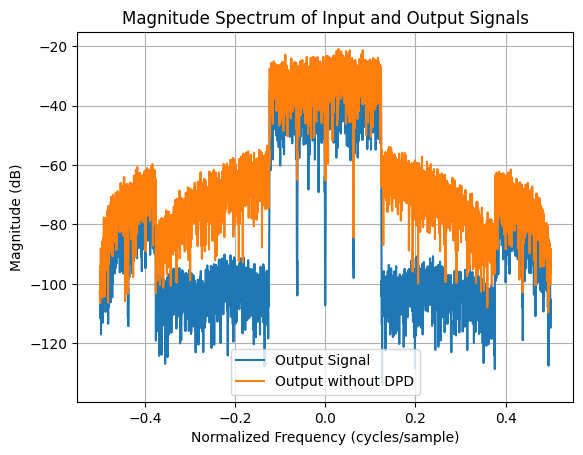

In [ ]:
# Train an inverse model based on this forward model
# Instantiate a new PNTDNN model for training (one layer)

PNTDNN_inverse_nn = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type='OneLayerNetwork', nn_file_path=None, forward_model=False)
# Create a datapath with this model and the forward model
datapath_pntdnn_one_layer = Datapath(forward_model=PNTDNN_three_layer_forward_nn, inverse_model=PNTDNN_inverse_nn)

datapath_pntdnn_one_layer.train_using_ila(
    training_dataset = openDPD_dataManager.training_dataset,
    valid_dataset = openDPD_dataManager.validation_dataset,
    iterations = 25,
    retrain_epochs_per_iteration=50,
    seq_length=None
)

# find nmse
nmse = datapath_pntdnn_one_layer.calculate_nmse(openDPD_dataManager.test_dataset.input_data)
print(f"NMSE: {nmse:.4f} dB")

# Plot the spectrum 
datapath_pntdnn_one_layer.plot_spectrum(openDPD_dataManager.test_dataset.input_data[:5000])

In [3]:
# Save inverse model
PNTDNN_inverse_nn.write_nn_to_file('pntdnn_inverse_model_open.pt')

Using cuda device
Raw PA Output (no DPD):
Total subcarriers (1 carrier): 1024, Active (after guard band filtering): 982


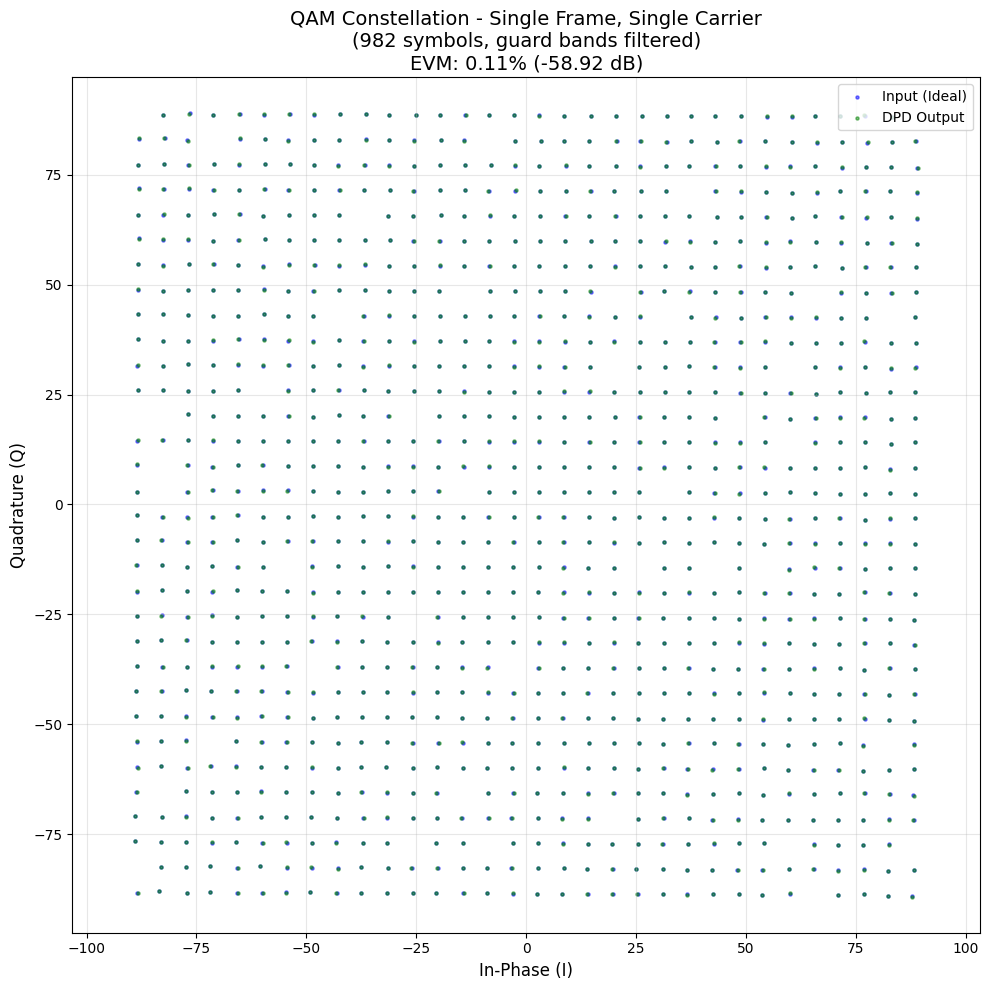

EVM (RMS): 0.113%
EVM (dB): -58.921 dB


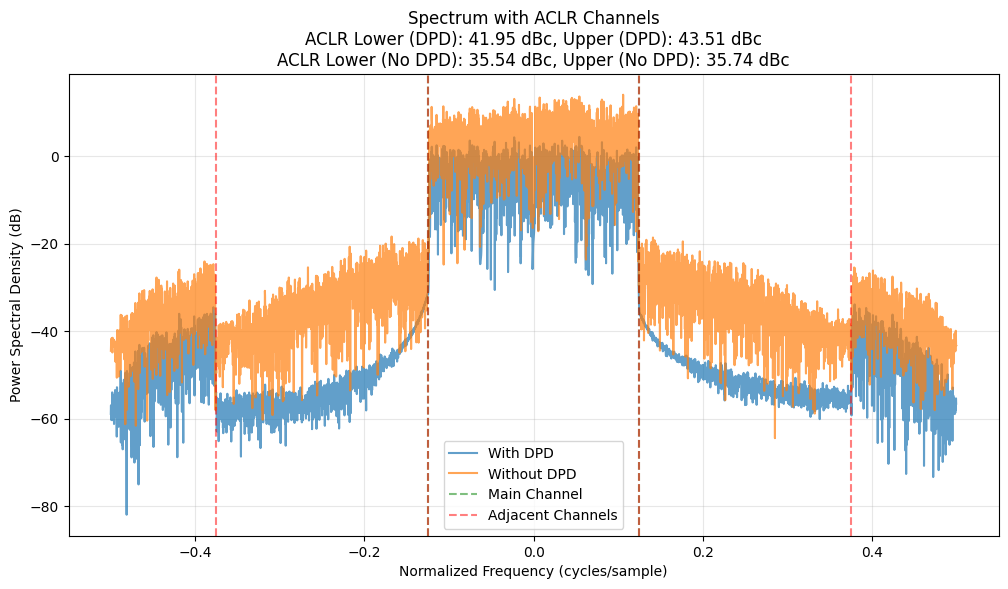

NMSE: (No DPD) 5.7197 dB


In [ ]:
PNTDNN_inverse_nn = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type='OneLayerNetwork', nn_file_path='pntdnn_inverse_model_open.pt', forward_model=False)
datapath_pntdnn_one_layer = Datapath(forward_model=PNTDNN_three_layer_forward_nn, inverse_model=PNTDNN_inverse_nn)

# Evaluate model performance before pruning
openDPD_fs = 640e6  # Sampling frequency: 640 MHz
openDPD_bw_main_ch = 160e6  # Main channel bandwidth: 160 MHz
openDPD_bw_sub_ch = 40e6  # Sub-channel bandwidth: 40 MHz
openDPD_n_sub_ch = 4  # Number of sub-channels
openDPD_nperseg = 16384  # FFT size (frame length)

# Plot the QAM constellation - First check raw PA output (should be distorted)
print("Raw PA Output (no DPD):")
datapath_pntdnn_one_layer.plot_constellation(openDPD_dataManager.training_dataset, fs = openDPD_fs, bw_sub_ch = openDPD_bw_sub_ch, n_sub_ch = openDPD_n_sub_ch, nperseg = openDPD_nperseg, show_dpd_output=True)

datapath_pntdnn_one_layer.plot_spectrum_with_aclr(
    openDPD_dataManager.test_dataset.input_data[:5000],
    channel_bw=0.25,
    channel_spacing=0.25
)

print(f"NMSE: (No DPD) {openDPD_dataManager.test_dataset.calculate_nmse():.4f} dB")


Pruning Iteration 1/10
Pruning 20.0% of remaining weights...
Current pruning: 20.00% of weights are zero
Retraining for 100 epochs...
Epoch  10/100  Loss=1.7465e-03  Valid Loss=3.0275e+01  LR=1.00e-03
Epoch  20/100  Loss=1.4631e-03  Valid Loss=3.0363e+01  LR=1.00e-03
Epoch  30/100  Loss=1.3712e-03  Valid Loss=3.0197e+01  LR=5.00e-04
Epoch  40/100  Loss=1.3265e-03  Valid Loss=2.9911e+01  LR=2.50e-04
Epoch  50/100  Loss=1.2998e-03  Valid Loss=2.9753e+01  LR=2.50e-04
Epoch  60/100  Loss=1.2746e-03  Valid Loss=2.9627e+01  LR=2.50e-04
Epoch  70/100  Loss=1.2497e-03  Valid Loss=2.9567e+01  LR=2.50e-04
Epoch  80/100  Loss=1.2235e-03  Valid Loss=2.9516e+01  LR=2.50e-04
Epoch  90/100  Loss=1.1998e-03  Valid Loss=2.9439e+01  LR=2.50e-04
Epoch 100/100  Loss=1.1769e-03  Valid Loss=2.9355e+01  LR=2.50e-04

Best model from epoch 100 with validation loss: 2.9355e+01
Iteration 1/1 (Block 1/18, samples 0-16384) - NMSE: -51.4117 dB
--------------------------------------------------
NMSE: -50.8121 dB

P

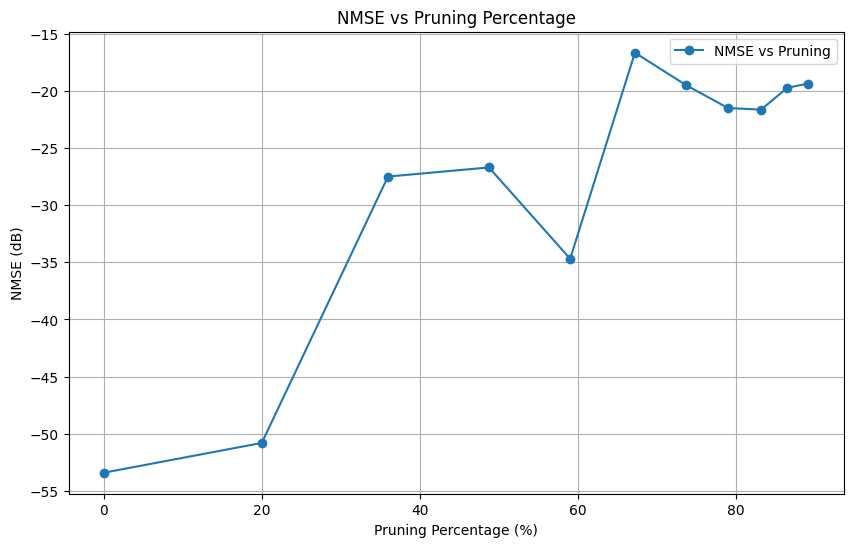

In [4]:
# Now prune the inverse model and evaluate performance again
pruning_experiment_pntdnn_one_layer = DatapathPruningExperiment(
    datapath=datapath_pntdnn_one_layer,
    training_dataset=openDPD_dataManager.training_dataset,
    validation_dataset=openDPD_dataManager.validation_dataset,
    test_dataset=openDPD_dataManager.test_dataset,
    num_prune_iterations=10,
    prune_amount=0.2,
    retrain_epochs=100,
    ila_iterations=1,
    nmse_tolerance=3,
    seq_length=16384
)

pruning_experiment_pntdnn_one_layer.run()

# Save the best linear pruned inverse model
pruning_experiment_pntdnn_one_layer.best_datapath.inverse_model.write_nn_to_file('pntdnn_one_layer_fixed_percentage_pruned_inverse_model_open.pt')


Using cuda device
Sparsity of pruned model: 0.00%
Total subcarriers (1 carrier): 1024, Active (after guard band filtering): 982


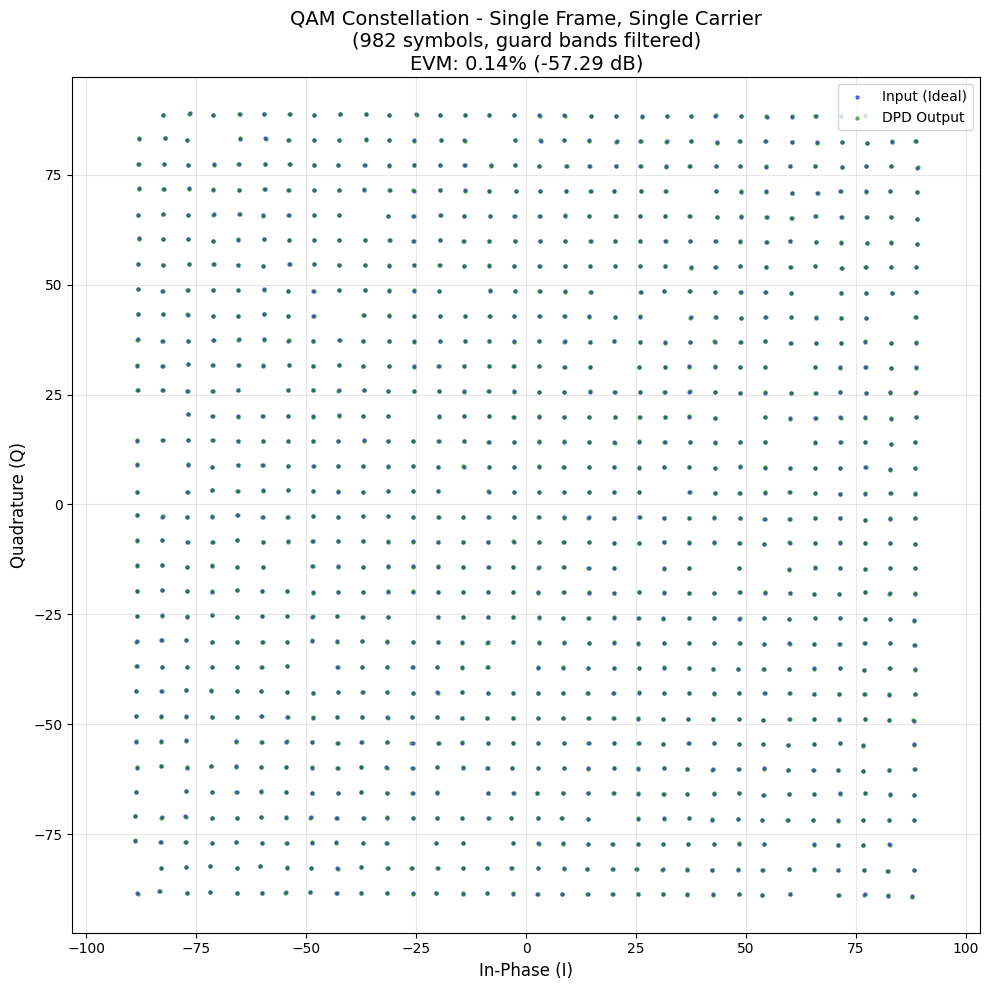

EVM (RMS): 0.137%
EVM (dB): -57.287 dB


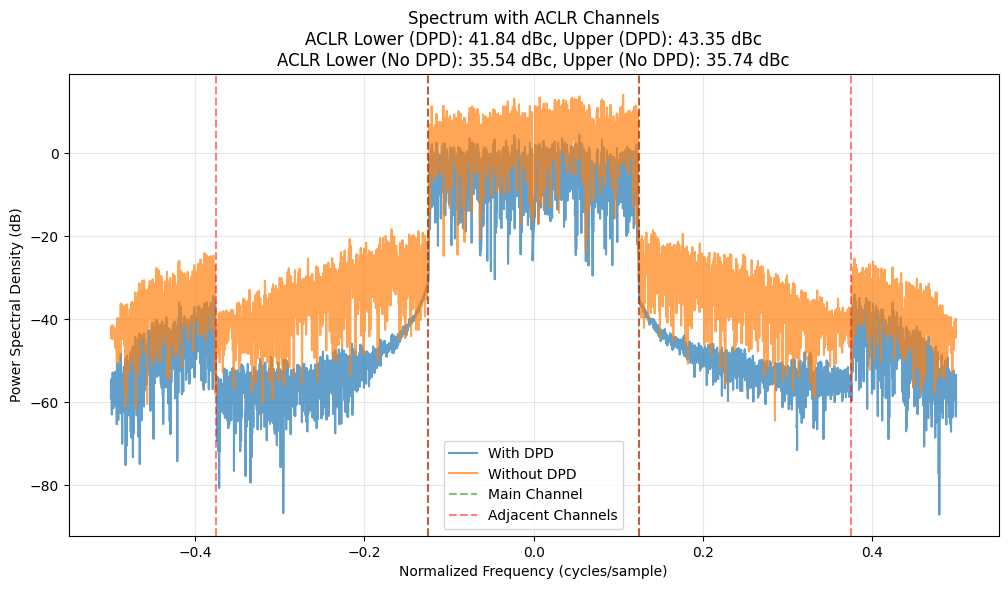

In [ ]:
# Load best linear pruned model and evaluate performance
best_pruned_inverse_nn = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type='OneLayerNetwork', nn_file_path='pntdnn_one_layer_fixed_percentage_pruned_inverse_model_open.pt', forward_model=False)
#print sparsity of pruned model
print(f"Sparsity of pruned model: {best_pruned_inverse_nn._get_pruning_percentage():.2f}%")

best_pruned_datapath = Datapath(forward_model=PNTDNN_three_layer_forward_nn, inverse_model=best_pruned_inverse_nn)
# Plots for of best model
best_pruned_datapath.plot_constellation(openDPD_dataManager.training_dataset, fs = openDPD_fs, bw_sub_ch = openDPD_bw_sub_ch, n_sub_ch = openDPD_n_sub_ch, nperseg = openDPD_nperseg, show_dpd_output=True)
best_pruned_datapath.plot_spectrum_with_aclr(openDPD_dataManager.test_dataset.input_data[:5000], channel_bw=0.25, channel_spacing=0.25)


Step 1  |  fraction = 20.00%
Pruning 20.00% of remaining weights...
Current sparsity: 20.00% of weights are zero
Retraining for 100 epochs...
Epoch  10/100  Loss=2.2989e-02  Valid Loss=2.2873e+01  LR=1.00e-03
Epoch  20/100  Loss=2.0993e-02  Valid Loss=2.2976e+01  LR=1.00e-03
Epoch  30/100  Loss=1.8091e-02  Valid Loss=2.2279e+01  LR=5.00e-04
Epoch  40/100  Loss=1.8420e-02  Valid Loss=2.1935e+01  LR=5.00e-04
Epoch  50/100  Loss=1.8329e-02  Valid Loss=2.1862e+01  LR=5.00e-04
Epoch  60/100  Loss=1.8280e-02  Valid Loss=2.1788e+01  LR=5.00e-04
Epoch  70/100  Loss=1.8253e-02  Valid Loss=2.1705e+01  LR=5.00e-04
Epoch  80/100  Loss=1.8237e-02  Valid Loss=2.1647e+01  LR=5.00e-04
Epoch  90/100  Loss=1.8227e-02  Valid Loss=2.1584e+01  LR=5.00e-04
Epoch 100/100  Loss=1.8220e-02  Valid Loss=2.1521e+01  LR=5.00e-04

Best model from epoch 100 with validation loss: 2.1521e+01
Iteration 1/1 (Block 1/1, samples 0-294912) - NMSE: -51.3746 dB
--------------------------------------------------
NMSE: -51.49

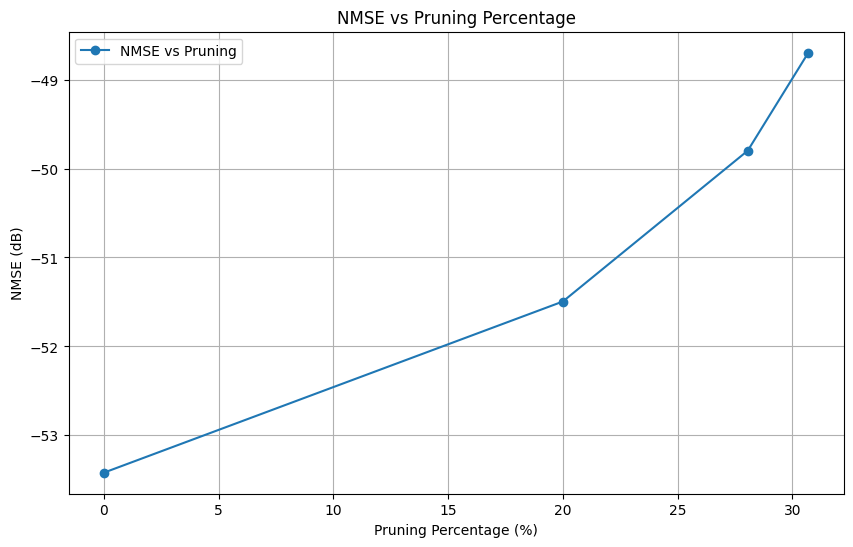

Best NMSE after pruning: -48.6978 dB


In [10]:
# Now try an adaptive pruning approach


adaptive_pruning_experiment = AdaptiveDatapathPruningExperiment(
    datapath=datapath_pntdnn_one_layer,
    training_dataset=openDPD_dataManager.training_dataset,
    validation_dataset=openDPD_dataManager.validation_dataset,
    test_dataset=openDPD_dataManager.test_dataset,
    retrain_epochs=100,
    ila_iterations = 1,
    initial_prune_fraction=0.2,
    max_prune_fraction=0.5,
    min_prune_fraction=0.01,
    nmse_tolerance=5
)

adaptive_pruning_experiment.run()

print("Best NMSE after pruning: {:.4f} dB".format(adaptive_pruning_experiment.best_datapath.calculate_nmse(openDPD_dataManager.test_dataset.input_data)))

In [11]:
# Save best adaptive pruned model
pntdnn_best_adaptive_pruned_model = adaptive_pruning_experiment.best_datapath.inverse_model
pntdnn_best_adaptive_pruned_model.write_nn_to_file('pntdnn_one_layer_adaptive_pruned_inverse_model_open.pt')

Using cuda device
Total subcarriers (1 carrier): 1024, Active (after guard band filtering): 982


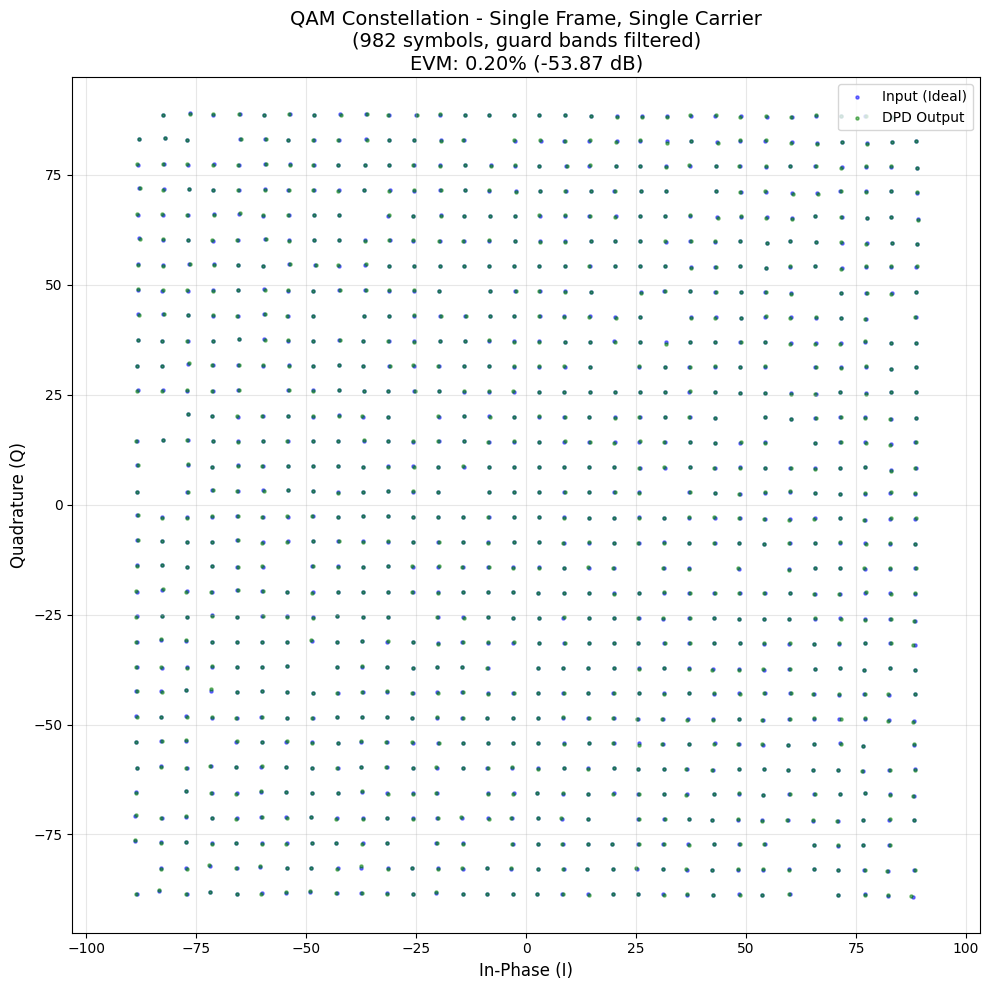

EVM (RMS): 0.203%
EVM (dB): -53.867 dB


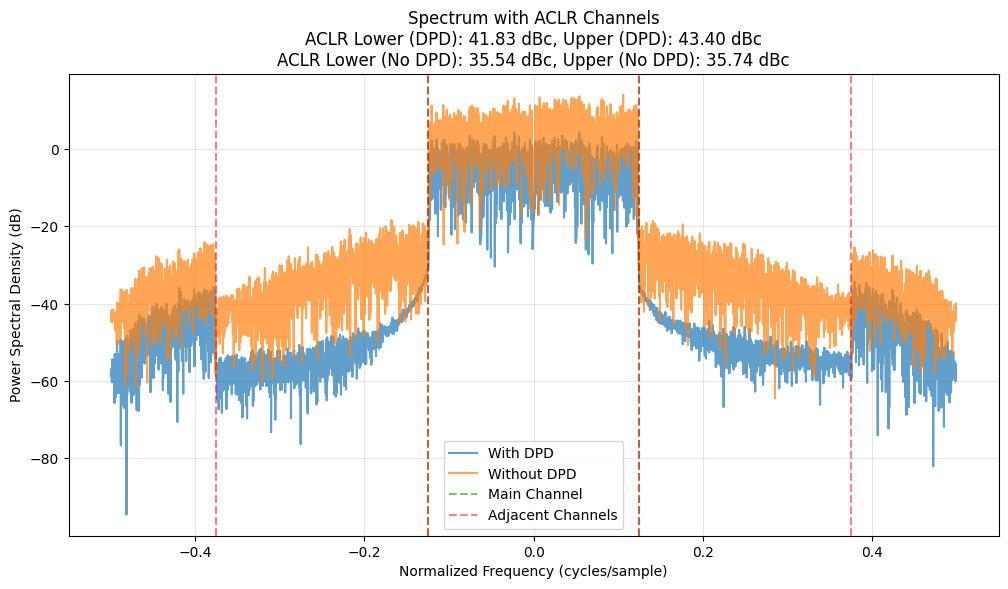

In [12]:
# load the adaptive best, and find its performance
best_adaptive_pruned_inverse_nn = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type='OneLayerNetwork', nn_file_path='pntdnn_one_layer_adaptive_pruned_inverse_model_open.pt', forward_model=False)
best_adaptive_pruned_datapath = Datapath(forward_model=PNTDNN_three_layer_forward_nn, inverse_model=best_adaptive_pruned_inverse_nn)
best_adaptive_pruned_datapath.plot_constellation(openDPD_dataManager.training_dataset, fs = openDPD_fs, bw_sub_ch = openDPD_bw_sub_ch, n_sub_ch = openDPD_n_sub_ch, nperseg = openDPD_nperseg, show_dpd_output=True)
best_adaptive_pruned_datapath.plot_spectrum_with_aclr(openDPD_dataManager.test_dataset.input_data[:5000], channel_bw=0.25, channel_spacing=0.25)

# PG-JANET one layer

In [ ]:
# Train an inverse model based on this forward model
# Instantiate a new PG-JANET model for training (one layer)

PGJANET_inverse_nn = PGJANET_NeuralNetwork(num_memory_levels=15, model_type='PGJANETNetwork', nn_file_path=None, forward_model=False, batch_size=512, hidden_size=16)
# Create a datapath with this model and the forward model
datapath_pgjanet_one_layer = Datapath(forward_model=PNTDNN_three_layer_forward_nn, inverse_model=PGJANET_inverse_nn)

datapath_pgjanet_one_layer.train_using_ila(
    training_dataset = openDPD_dataManager.training_dataset,
    valid_dataset = openDPD_dataManager.validation_dataset,
    iterations = 10,
    retrain_epochs_per_iteration=50,
    seq_length=16834
)

# find nmse
nmse = datapath_pgjanet_one_layer.calculate_nmse(openDPD_dataManager.test_dataset.input_data)
print(f"NMSE: {nmse:.4f} dB")

# Plot the spectrum 
datapath_pgjanet_one_layer.plot_spectrum(openDPD_dataManager.test_dataset.input_data[:5000])

Using cuda device
Epoch  10/50  Loss=3.6450e-03  Valid Loss=4.7411e+03  LR=1.00e-03
Epoch  20/50  Loss=3.2626e-03  Valid Loss=4.4387e+03  LR=1.00e-03


In [ ]:
# Save inverse model
PGJANET_inverse_nn.write_nn_to_file('pgjanet_inverse_model_open.pt')

In [ ]:
PGJANET_inverse_nn = PGJANET_NeuralNetwork(num_memory_levels=15, model_type='PGJANETNetwork', nn_file_path='pgjanet_inverse_model_open.pt', forward_model=False)
datapath_pgjanet_one_layer = Datapath(forward_model=PNTDNN_three_layer_forward_nn, inverse_model=PGJANET_inverse_nn)

# Evaluate model performance before pruning
openDPD_fs = 640e6  # Sampling frequency: 640 MHz
openDPD_bw_main_ch = 160e6  # Main channel bandwidth: 160 MHz
openDPD_bw_sub_ch = 40e6  # Sub-channel bandwidth: 40 MHz
openDPD_n_sub_ch = 4  # Number of sub-channels
openDPD_nperseg = 16384  # FFT size (frame length)

# Plot the QAM constellation - First check raw PA output (should be distorted)
print("Raw PA Output (no DPD):")
datapath_pgjanet_one_layer.plot_constellation(openDPD_dataManager.training_dataset, fs = openDPD_fs, bw_sub_ch = openDPD_bw_sub_ch, n_sub_ch = openDPD_n_sub_ch, nperseg = openDPD_nperseg, show_dpd_output=True)

datapath_pgjanet_one_layer.plot_spectrum_with_aclr(
    openDPD_dataManager.test_dataset.input_data[:5000],
    channel_bw=0.25,
    channel_spacing=0.25
)

print(f"NMSE: (No DPD) {openDPD_dataManager.test_dataset.calculate_nmse():.4f} dB")

In [ ]:
# Now prune the inverse model and evaluate performance again
pruning_experiment_pgjanet_one_layer = DatapathPruningExperiment(
    datapath=datapath_pgjanet_one_layer,
    training_dataset=openDPD_dataManager.training_dataset,
    validation_dataset=openDPD_dataManager.validation_dataset,
    test_dataset=openDPD_dataManager.test_dataset,
    num_prune_iterations=10,
    prune_amount=0.2,
    retrain_epochs=100,
    ila_iterations=1,
    nmse_tolerance=3,
    seq_length=16384
)

pruning_experiment_pgjanet_one_layer.run()

# Save the best linear pruned inverse model
pruning_experiment_pgjanet_one_layer.best_datapath.inverse_model.write_nn_to_file('pgjanet_one_layer_fixed_percentage_pruned_inverse_model_open.pt')

In [ ]:
# Load best linear pruned model and evaluate performance
best_pruned_pgjanet_inverse_nn = PGJANET_NeuralNetwork(num_memory_levels=15, model_type='PGJANETNetwork', nn_file_path='pgjanet_one_layer_fixed_percentage_pruned_inverse_model_open.pt', forward_model=False)
#print sparsity of pruned model
print(f"Sparsity of pruned model: {best_pruned_pgjanet_inverse_nn._get_pruning_percentage():.2f}%")

best_pruned_pgjanet_datapath = Datapath(forward_model=PNTDNN_three_layer_forward_nn, inverse_model=best_pruned_pgjanet_inverse_nn)
# Plots for of best model
best_pruned_pgjanet_datapath.plot_constellation(openDPD_dataManager.training_dataset, fs = openDPD_fs, bw_sub_ch = openDPD_bw_sub_ch, n_sub_ch = openDPD_n_sub_ch, nperseg = openDPD_nperseg, show_dpd_output=True)
best_pruned_pgjanet_datapath.plot_spectrum_with_aclr(openDPD_dataManager.test_dataset.input_data[:5000], channel_bw=0.25, channel_spacing=0.25)

In [ ]:
# Now try an adaptive pruning approach


adaptive_pruning_pgjanet_experiment = AdaptiveDatapathPruningExperiment(
    datapath=datapath_pgjanet_one_layer,
    training_dataset=openDPD_dataManager.training_dataset,
    validation_dataset=openDPD_dataManager.validation_dataset,
    test_dataset=openDPD_dataManager.test_dataset,
    retrain_epochs=100,
    ila_iterations = 1,
    initial_prune_fraction=0.2,
    max_prune_fraction=0.5,
    min_prune_fraction=0.01,
    nmse_tolerance=5
)

adaptive_pruning_pgjanet_experiment.run()

print("Best NMSE after pruning: {:.4f} dB".format(adaptive_pruning_pgjanet_experiment.best_datapath.calculate_nmse(openDPD_dataManager.test_dataset.input_data)))

In [ ]:
# Save best adaptive pruned model
pgjanet_best_adaptive_pruned_model = adaptive_pruning_pgjanet_experiment.best_datapath.inverse_model
pgjanet_best_adaptive_pruned_model.write_nn_to_file('pgjanet_one_layer_adaptive_pruned_inverse_model_open.pt')

In [ ]:
# load the adaptive best, and find its performance
best_adaptive_pruned_pgjanet_inverse_nn = PGJANET_NeuralNetwork(num_memory_levels=15, model_type='PGJANETNetwork', nn_file_path='pgjanet_one_layer_adaptive_pruned_inverse_model_open.pt', forward_model=False)
best_adaptive_pruned_pgjanet_datapath = Datapath(forward_model=PNTDNN_three_layer_forward_nn, inverse_model=best_adaptive_pruned_pgjanet_inverse_nn)
best_adaptive_pruned_pgjanet_datapath.plot_constellation(openDPD_dataManager.training_dataset, fs = openDPD_fs, bw_sub_ch = openDPD_bw_sub_ch, n_sub_ch = openDPD_n_sub_ch, nperseg = openDPD_nperseg, show_dpd_output=True)
best_adaptive_pruned_pgjanet_datapath.plot_spectrum_with_aclr(openDPD_dataManager.test_dataset.input_data[:5000], channel_bw=0.25, channel_spacing=0.25)